# Cleaning and Averaging Light Curves

This iPython notebook will help you apply each cut with a greater degree of control than an automatic cleaning. You will be walked through the following:
1. ATLAS template change correction
2. Static uncertainty cut
3. Estimating true uncertainties
4. Dynamic chi-square cut
5. Control light curve cut
6. Averaging the light curve and cutting bad bins
7. Save files

When running a cell, the descriptions located above that cell will help you interpret the plots and make decisions about the supernova.

In order for this notebook to work correctly, the light curves must already be downloaded and saved in ATClean-readable format. To download ATLAS light curves in ATClean-readable format, please refer to the documentation `README.md` and use the download script `download.py`. To convert existing Rubin, ATLAS, or TESS light curves to ATClean-readable format, please refer to the documentation `README.md` and use the conversion script `convert.py`.


[View our paper here](https://iopscience.iop.org/article/10.3847/1538-4357/ad973d) for details on our cleaning and binning method, as well as our pre-SN outburst detection process!

## Settings 
### Load the config file and preset column names

In [1]:
# ==== User Settings ====

# Enter the config file name:
CONFIG_FILE = "config.ini"

# Enter the column name preset to use 
# (see config file for more; options: "atlas", "rubin", "tess"):
PRESET = "atlas"

# =======================

import sys
import numpy as np
from copy import deepcopy
from functools import reduce
sys.path.insert(1,'../')

from download import load_config, make_dir_if_not_exists
from lightcurve import PresetColumnNames, Supernova, LimCutsTable
from plot import Plot, PlotLimits
from utils import (
    UncertaintyEstimation, 
    UncertaintyCut,
    ChiSquareCut, 
    ControlLightCurveCut, 
    CustomCut,
    BadDayCut, 
    CutList, 
    hexstring_to_int, 
    reformat_dir
)

# load config
config = load_config(CONFIG_FILE)

# load preset
print(f"\nLoading {PRESET} preset column names from {CONFIG_FILE}...")
colnames = PresetColumnNames(config, PRESET)
print(colnames.__str__())


Loading config file at config.ini...

Loading atlas preset column names from config.ini...
--- Required Columns ---
mjd: MJD
flux: uJy
dflux: duJy
--- Optional Columns ---
chisquare: chi/N
filt: F
mag: m
dmag: dm
ra: RA
dec: Dec
--- Extra Columns to Copy ---
x, y, maj, min, phi, apfit, mag5sig, Sky, Obs


### Load the light curves and set up the output README file

In [2]:
# ==== User Settings ====

# Enter the target SN name:
TNSNAME = '2023zkd'

# Enter the path to the data directory that contains the ATClean-readable SN directories:
INPUT_DIR = config["dir"]["atclean_input"]

# Enter the path to the directory that contains cleaned and binned light curves, plots, and more:
OUTPUT_DIR = config["dir"]["output"]

# Automatically save the generated plots in this notebook?:
SAVE_PLOTS = True
# Enter the path to a directory to optionally save plots:
PLOTS_DIR = f'{OUTPUT_DIR}/{TNSNAME}/plots'

# Enter the path of a new text file that will contain records of each cut applied, etc.: 
README_PATH = f'{OUTPUT_DIR}/{TNSNAME}/{TNSNAME}_output.md'

# Enter the filter for this light curve:
FILT = 'o'

# Enter the SN's discovery date:
DISCOVERY_DATE = 60112.192000

# Set to True if you are planning on applying the control light curve cut 
# and have already downloaded the control light curves:
LOAD_CONTROLS = True
# Enter the number of control light curves to load:
NUM_CONTROLS = int(config["download"]["num_controls"])

# =======================

# make sure tnsname not attached to end of input and output dirs
INPUT_DIR = reformat_dir(INPUT_DIR, TNSNAME)
OUTPUT_DIR = reformat_dir(OUTPUT_DIR, TNSNAME)

print(f'SN {TNSNAME}, filter {FILT}', end='')
if not DISCOVERY_DATE is None:
    print(f', discovery date: {DISCOVERY_DATE}')
print(f'Source directory (load light curves): {INPUT_DIR}/{TNSNAME}')
print(f'Output directory (save cleaned and binned light curves): {OUTPUT_DIR}/{TNSNAME}')
print(f'Plots directory (save plots): {PLOTS_DIR}')

# load light curves
sn = Supernova(colnames, tnsname=TNSNAME, mjd0=DISCOVERY_DATE, filt=FILT)
sn.load_all(INPUT_DIR, NUM_CONTROLS)
sn.prep_for_cleaning(verbose=True)

make_dir_if_not_exists(f'{OUTPUT_DIR}/{TNSNAME}')

def write_to_file(file_path, text, mode="a"):
    """Write text to a file, handling errors gracefully."""
    if mode not in {"w", "a"}:
        raise ValueError("Invalid mode. Use 'w' for overwrite or 'a' for append.")

    try:
        with open(file_path, mode, encoding='utf-8') as f:
            f.write(text)
        return True
    except Exception as e:
        print(f'WARNING: Could not save text to {file_path}: {e}')
        return False  

# for new text file that will contain record of each cut, etc.
file_outputs = {}
file_outputs['intro'] = f'# SN {sn.tnsname} Light Curve Cleaning and Averaging (via clean.ipynb)\n\nFilter: {sn.filt}\nDiscovery date: {sn.mjd0} MJD\nNumber of control light curves: {sn.num_controls}'

p = Plot(PLOTS_DIR)

cut_list = CutList()

SN 2023zkd, filter o, discovery date: 60112.192
Source directory (load light curves): /Users/sofiarest/Desktop/Supernovae/data_refactor/atclean_input/2023zkd
Output directory (save cleaned and binned light curves): /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2023zkd
Plots directory (save plots): /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2023zkd/plots

Loading SN light curve and 8 control light curves...
Successfully loaded SN light curve and 8 control light curves (control indices: [1, 2, 3, 4, 5, 6, 7, 8])
Adding blank 'Mask' columns, replacing infs with NaNs, and calculating flux/dflux...
Success

Making sure SN and control light curve MJDs match up exactly:
MJDs out of agreement for control light curve 1, fixing...
MJDs out of agreement for control light curve 2, fixing...
MJDs out of agreement for control light curve 3, fixing...
MJDs out of agreement for control light curve 4, fixing...
MJDs out of agreement for control light curve 5, fixing..

### Plot the loaded SN and control light curves

Saving plot: /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2023zkd/plots/original.png


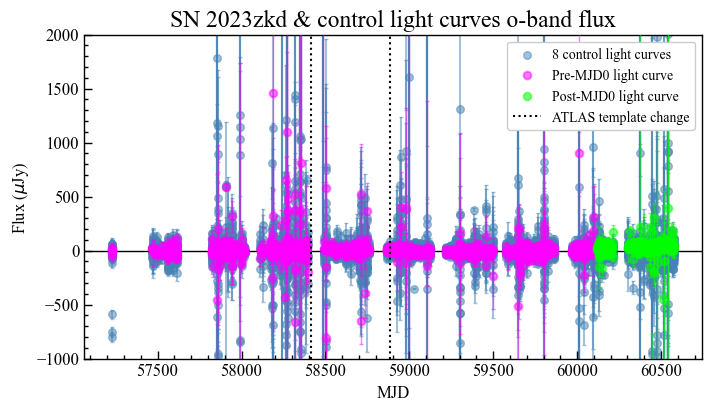

In [3]:
# ==== User Settings ====

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = -1000
YLIM_UPPER = 2000

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_SN(
    sn,
    p.get_lims(lc=sn.lcs[0], custom_lims=custom_lims),
    plot_controls=True,
    plot_template_changes=True,
    save=SAVE_PLOTS
)

## 1. ATLAS template change correction

This notebook takes into account ATLAS's periodic replacement of the difference image reference templates, which may cause step discontinuities in flux. Two template changes have been recorded at MJDs 58417 and 58882. More information can be found here: https://fallingstar-data.com/forcedphot/faq/.

We aid the user in adding offset flux to different regions of the ATLAS light curve in order to correct for these step discontinuities.

### View the light curve before template correction

Setting current flux offset to 0...
            MJD       m     dm  uJy  duJy  F  err  chi/N         RA      Dec        x        y   maj   min   phi  apfit  mag5sig    Sky             Obs  Mask  flux/dflux  uJy_offset
0  57230.267141  21.203  4.312   12    52  o    0   1.05  237.19811  9.20004  2955.95  8405.18  3.63  3.55   9.8 -0.418    18.51  19.53  02a57230o0033o     0    0.230769           0
1  57230.276657 -20.946  3.263  -15    50  o    0   1.05  237.19811  9.20004  2954.48  8406.59  3.79  3.67  -8.2 -0.409    18.47  19.53  02a57230o0044o     0   -0.300000           0
2  57230.301745  21.765  6.444    7    46  o    0   0.99  237.19811  9.20004  1494.40  9889.15  3.72  3.51 -13.4 -0.464    18.49  19.48  02a57230o0078o     0    0.152174           0
3  57230.304669  20.298  1.571   28    43  o    0   0.86  237.19811  9.20004  7747.03   194.15  3.75  3.53 -76.2 -0.436    18.52  19.55  02a57230o0082o     0    0.651163           0
4  57230.318656 -19.578  0.833  -54    45  o    0   0.

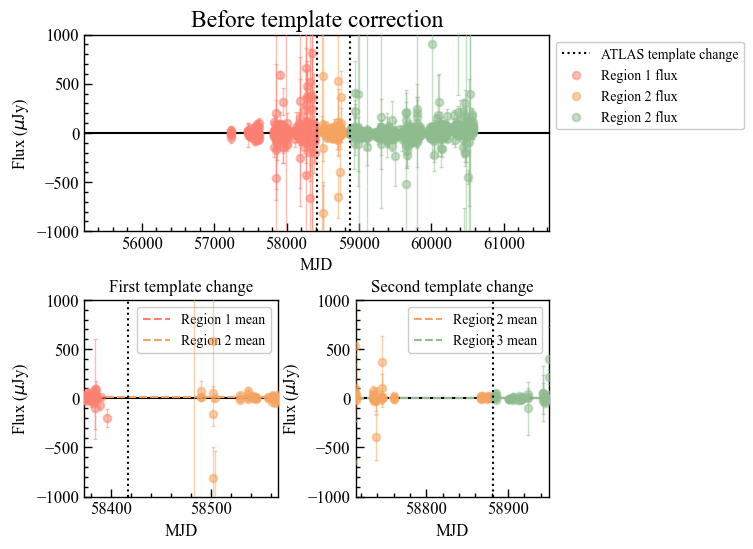

In [4]:
# ==== User Settings ====

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = -1000
YLIM_UPPER = 1000

# =======================

sn.lcs[0]._clear_flux_offset_column()

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

print(sn.lcs[0].t.head().to_string())

fig = p.plot_template_correction(
    sn.lcs[0], 
    p.get_lims(lc=sn.lcs[0], custom_lims=custom_lims), 
    title="Before template correction", 
    save=SAVE_PLOTS, 
    filename="before_template_correction"
)

### Apply template correction and view results

Proceeding with automatic template correction...
Subtracting previous offset from flux column...
Setting current flux offset to 0...
Corrective flux 3.00 uJy added to region 1
Corrective flux 0.00 uJy added to region 3
Corrective flux 4.00 uJy added to region global

             MJD  uJy  uJy_offset  duJy
0  57230.267141   19           7    52
1  57230.276657   -8           7    50
2  57230.301745   14           7    46
3  57230.304669   35           7    43
4  57230.318656  -47           7    45
Saving plot: /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2023zkd/plots/after_template_correction.png


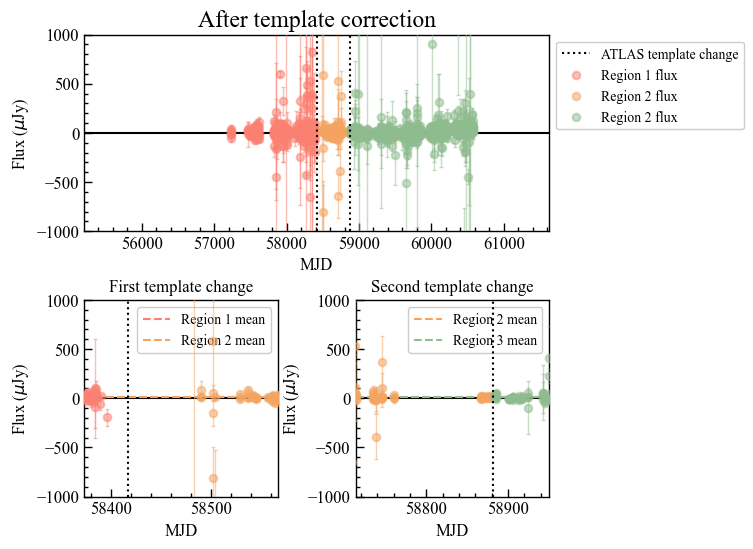

In [5]:
# ==== User Settings ====

# Optionally enter flux offsets for each region 
# (set each to None for automatic correction):
GLOBAL_OFFSET = None # 0
REGION1_OFFSET = None # 0 + global_offset
REGION2_OFFSET = None # 0 + global_offset
REGION3_OFFSET = None # 0 + global_offset

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = -1000
YLIM_UPPER = 1000

# =======================

output = sn.lcs[0].apply_template_correction(
    DISCOVERY_DATE, 
    maskval=0x1|0x2|0x400000|0x800000, 
    region1_offset=REGION1_OFFSET, 
    region2_offset=REGION2_OFFSET, 
    region3_offset=REGION3_OFFSET
)
print('\n'.join(output))
print('\n',sn.lcs[0].t[['MJD','uJy','uJy_offset','duJy']].head().to_string())
file_outputs['template_correction'] = '\n\n### ATLAS template change correction\n'+'\n'.join(output)

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_template_correction(
    sn.lcs[0], 
    p.get_lims(lc=sn.lcs[0], custom_lims=custom_lims), 
    title="After template correction", 
    save=SAVE_PLOTS, 
    filename="after_template_correction"
)

# 2. Static uncertainty cut

The following uncertainty cut implements a static cut that applies the same way to each light curve. The purpose of this cut is to identify and clean out the most egregious outliers with large uncertainties and small chi-square values that would not be cut out in the dynamic chi-square cut. The default value of this cut (160) was determined after calculating the typical uncertainty of bright stars just below the saturation limit. 

<div class="alert alert-block alert-warning">
    <b>Warning:</b> If the SN is particularly bright, you may want to increase the value of the cut and rerun this portion.
</div>


Applying uncertainty cut (Uncertainty Cut: column=duJy flag=0x2 max_value=160)...
Success
Total percent of SN light curve flagged with 0x2: 3.02%
Saving plot: /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2023zkd/plots/uncertainty_cut.png


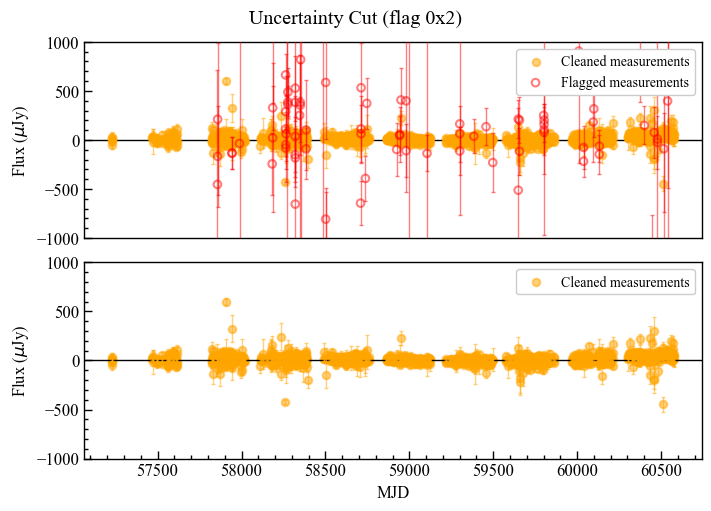

In [ ]:
# ==== User Settings ====

# You may change the following static uncertainty cut value to your liking;
# however, the default value is 160.
UNCERTAINTY_MAX_VALUE = 160

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = -1000
YLIM_UPPER = 1000

# =======================

uncertainty_cut = UncertaintyCut(
    sn.colnames.dflux, 
    max_value=UNCERTAINTY_MAX_VALUE, 
    flag=hexstring_to_int(config["uncert_cut"]["flag"])
)

print(f"\nApplying uncertainty cut ({uncertainty_cut})...")
percent_cut = sn.apply_cut(uncertainty_cut)
cut_list.add(uncertainty_cut)
print("Success")
print(
    f"Total percent of SN light curve flagged with {hex(uncertainty_cut.flag)}: {percent_cut:0.2f}%"
)

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_cut(
    sn.lcs[0],
    uncertainty_cut.flag,
    p.get_lims(
        lc=sn.lcs[0],
        indices=sn.lcs[0].get_good_indices(uncertainty_cut.flag),
        custom_lims=custom_lims
    ),
    title=UncertaintyCut.name(),
    save_filename="uncertainty_cut" if SAVE_PLOTS else None
)

file_outputs[UncertaintyCut.name()] = f"\n\n### Uncertainty cut\n\nSelected uncertainty max value of {uncertainty_cut.max_value}\n\nTotal percent of SN light curve flagged with {hex(uncertainty_cut.flag)}: {percent_cut:0.2f}%"

## 3. Estimating true uncertainties by calculating a systematic error contribution

This section attempts to account for an extra noise source in the data by estimating the true typical uncertainty, deriving the additional systematic uncertainty, and lastly applying this extra noise to a new uncertainty column. This new uncertainty column will be used in the cuts following this section.

`temp_x2_max_value`: A temporary, very high chi-square cut value used to eliminate the most egregious outliers from the data. This is an initial step in uncertainty estimation to ensure grossly incorrect data points are removed.

To read more about how we calculate the true uncertainties, please refer to Section 3.1.2 of our paper (link at the top of this notebook).

We can increase the typical uncertainties from 17.00 to 19.31 by adding an additional systematic uncertainty of 9.15 in quadrature
New typical uncertainty is 13.56% greater than old typical uncertainty
Apply true uncertainties estimation: True
True uncertainties estimation recommended
Applying procedure...
Success
The extra noise was added to the uncertainties of the SN light curve and copied to the 'duJy_new' column
Saving plot: /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2023zkd/plots/uncertainty_est.png


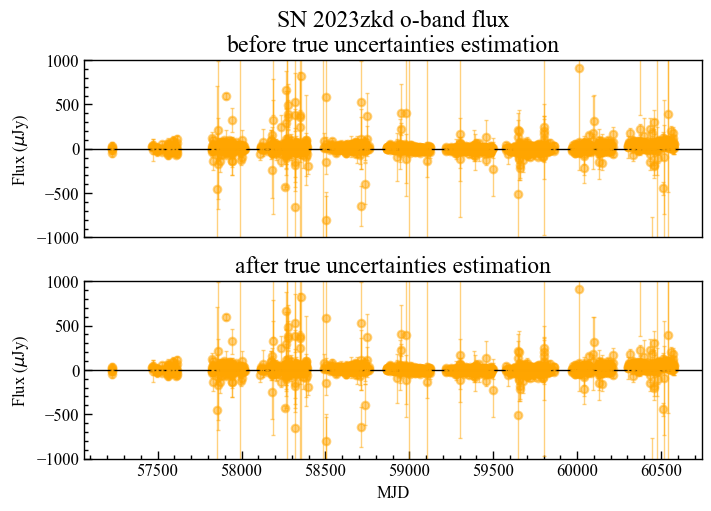

In [ ]:
# ==== User Settings ====

# Enter a preliminary chi-square cut (keep at a high number; default is 20):
TEMP_X2_MAX_VALUE = 20

# Apply this step?:
APPLY = True

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = -1000
YLIM_UPPER = 1000

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

uncertainty_estimation = UncertaintyEstimation(
    TEMP_X2_MAX_VALUE,
    hexstring_to_int(config["uncert_cut"]["flag"])
)

stats = sn.get_uncert_est_stats(uncertainty_estimation)
final_sigma_extra = np.median(stats["sigma_extra"])

sigma_typical_old = np.median(stats["median_dflux"])
sigma_typical_new = np.sqrt(final_sigma_extra**2 + sigma_typical_old**2)
percent_greater = 100 * (
    (sigma_typical_new - sigma_typical_old) / sigma_typical_old
)
print(
    f"We can increase the typical uncertainties from {sigma_typical_old:0.2f} to {sigma_typical_new:0.2f} by adding an additional systematic uncertainty of {final_sigma_extra:0.2f} in quadrature"
)
print(
    f"New typical uncertainty is {percent_greater:0.2f}% greater than old typical uncertainty"
)

file_outputs[UncertaintyEstimation.name()] = f'\n\n### True uncertainties estimation\n\nWe can increase the typical uncertainties from {sigma_typical_old:0.2f} to {sigma_typical_new:0.2f} by adding an additional systematic uncertainty of {final_sigma_extra:0.2f} in quadrature.\nNew typical uncertainty is {percent_greater:0.2f}% greater than old typical uncertainty.\nApply true uncertainties estimation: {APPLY}.'

print(f"Apply true uncertainties estimation: {APPLY}")
if percent_greater >= 10:
    print("True uncertainties estimation recommended")
    print(f'{"Applying" if APPLY else "Skipping"} procedure...')
    if APPLY:
        sn.add_noise_to_dflux(final_sigma_extra)
        cut_list.add(uncertainty_estimation)
        print("Success")
        print(
            f"The extra noise was added to the uncertainties of the SN light curve and copied to the '{sn.colnames.dflux}_new' column"
        )

        file_outputs[UncertaintyEstimation.name()] += f'\nTrue uncertainties estimation recommended.\nThe extra noise was added to the uncertainties of the SN light curve and copied to the {sn.colnames.dflux}_new column.'

        p.plot_uncert_est(
            sn.lcs[0],
            sn.tnsname,
            p.get_lims(
                lc=sn.lcs[0],
                indices=sn.lcs[0].get_good_indices(
                    hexstring_to_int(config["uncert_cut"]["flag"])
                ),
                custom_lims=custom_lims
            ),
            save=SAVE_PLOTS,
            filename="uncertainty_est"
        )
else:
    print("True uncertainties estimation not needed; skipping procedure")
    file_outputs[UncertaintyEstimation.name()] += '\nTrue uncertainties estimation not needed; procedure skipped.'


## 4. Dynamic PSF chi-square cut

We use two factors, <strong>contamination</strong> and <strong>loss</strong>, to analyze a PSF chi-square cut for the target SN, with flux/dflux as the deciding factor of what constitutes a good measurement vs. a bad measurement. 

We decide what will determine a good measurement vs. a bad measurement using a factor outside of the chi-square values. Our chosen factor is |flux/dflux|. The recommended boundary is a value of 3, such that any measurements with |flux/dflux| <= 3 are regarded as "good" measurements, and any measurements with |flux/dflux| > 3 are regarded as "bad" measurements. You can set this boundary to a different number by changing the value of `snr_bound` below. 

We aim to separate good measurements from bad using the calculated chi-square cut by <strong>minimizing as much loss *and* contamination as possible</strong>. 
- We define contamination $C$ for a certain chi-square cut to be the number of bad kept measurements over the total number of kept measurements.
    - $C = N_{bad, kept}/N_{kept}$
- We define loss $L$ for a certain chi-square cut to be the number of good cut measurements over the total number of good measurements.
    - $L = N_{good,cut}/N_{good}$
- We set the upper and lower bounds of a range of possible cuts for which to calculate $C$ and $L$. We start at a low value of 3 (which can be changed by setting the value of `cut_start` below) and end at 50 (this value is inclusive and can be changed by setting the value of `cut_stop` below) with a step size of 1 (`cut_step` below). For chi-square cuts falling on or between `cut_start` and `cut_stop` in increments of `cut_step`, we can begin to calculate contamination and loss percentages.
- Since we can assume that the expected value of the control light curve flux is 0, we use these measurements by default to calculate and plot contamination and loss for the range of possible cuts.

We set our default chi-square cut to 10, and defer overriding of that cut for a particular SN to the user, given informative plots on alternative cuts with respect to contamination and loss. The user can override this cut by changing the `x2_max_value` field and rerunning the following cells.

To read more about this cut, please refer to Section 3.1.3 of our paper (link at the top of this notebook).

<div class="alert alert-block alert-warning">
<b>Warning:</b> For very bright SNe, the chi-square values may increase during the SN even for good measurements due to imperfection in PSF fitting. Therefore, we recommend that the user double-check the chi-square values (or this section's plots) to verify that the cut is working as intended, and override the cut with a custom value if needed. The user can rerun the following cells in order to reapply a custom cut.
</div>

### View contamination and loss for a selected range of chi-square cuts and choose your desired cut

Using control light curves to determine contamination and loss
Calculating loss and contamination for chi-square cuts from 3 to 50...


/Users/sofiarest/My Drive/College/STScI Research Paper/atclean/lightcurve.py:1307: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.t = pd.concat([self.t, pd.DataFrame([row])], ignore_index=True)


Success
Saving plot: /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2023zkd/plots/limcutstable.png

Selected chi-square cut of 10.00 has 0.96% contamination and 0.09% loss


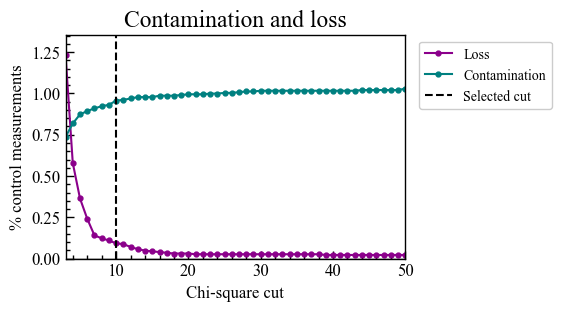

In [ ]:
# ==== User Settings ====

# You may change the following PSF chi-square cut value to your liking;
# however, the default value is 10.
X2_MAX_VALUE = 10

# Enter the bound that should separate a good |flux/dflux| measurement from a bad one
# (will be used when calculating contamination and loss):
SNR_BOUND = 3.0

# Enter the bounds for the range of possible chi-square cuts for which to 
# calculate contamination and loss (minimum cut, maximum cut, and step):
CUT_START = 3 # this is inclusive
CUT_STOP = 50 # this is inclusive
CUT_STEP = 1

# If set to True, we use the pre-SN light curve to calculate contamination and loss.
# If set to False, we use the control light curves (recommended).
USE_PRESN_LC = False

# =======================

if sn.colnames.chisquare is None:
    raise RuntimeError("No chi-square column name provided in config file; skipping procedure")

params = {
    "snr_bound": SNR_BOUND,
    "min_cut": CUT_START,
    "max_cut": CUT_STOP,
    "cut_step": CUT_STEP,
    "use_pre_mjd0_lc": USE_PRESN_LC,
}
x2_cut = ChiSquareCut(
    sn.colnames.chisquare,
    max_value=X2_MAX_VALUE,
    flag=hexstring_to_int(config["x2_cut"]["flag"]),
    snr_bound=SNR_BOUND,
    min_cut=CUT_START,
    max_cut=CUT_STOP,
    cut_step=CUT_STEP,
    use_pre_mjd0_lc=USE_PRESN_LC,
)

if x2_cut.use_pre_mjd0_lc:
    print("Using pre-MJD0 light curve to determine contamination and loss")
    if sn.mjd0 is None:
        raise RuntimeError(
            "MJD0 cannot be None. Please provide MJD0 throught the SN info table or --mjd0 argument, or set the use_pre_MJD0_lc field in the config file to False."
        )
    lc_temp = deepcopy(sn.lcs[0])
    ix = lc_temp.ix_inrange(lc_temp.colnames.mjd, uplim=sn.mjd0)
    if len(ix) < 1:
        raise RuntimeError("no pre-MJD0 light curve available")
else:
    print("Using control light curves to determine contamination and loss")
    if sn.num_controls < 1:
        raise RuntimeError(
            "No control light curves loaded. Use the --num_controls argument to load control light curves, or change the [x2_cut][use_pre_mjd0_lc] field to True."
        )
    lc_temp = sn.get_all_controls()
    ix = lc_temp.t.index.values

limcuts = LimCutsTable(lc_temp, x2_cut.snr_bound, indices=ix)
limcuts.calculate_table(
    x2_cut.min_cut, x2_cut.max_cut, x2_cut.cut_step
)
print("Success")
fig = p.plot_limcuts(limcuts, x2_cut, save=SAVE_PLOTS)

data = limcuts.calculate_row(x2_cut.max_value)
print(
    f'\nSelected chi-square cut of {x2_cut.max_value:0.2f} has {data["Pcontamination"]:0.2f}% contamination and {data["Ploss"]:0.2f}% loss'
)

### Plot the flux/dflux distribution

The following histogram displays the flux/dflux distribution of the SN and control light curves. In green, we plot flux/dflux (µJy/dµJy) measurements with a chi-square value less than or equal to `x2_cut`, which is currently set to 5 below; in red, we plot flux/dflux (µJy/dµJy) measurements with a chi-square value greater than `x2_cut`. 

Ideally, all measurements with chi-square value <= `x2_cut` should have |µJy/dµJy| <= `fdf_bound`, and measurements with chi-square > `x2_cut` should have |µJy/dµJy| > `fdf_bound`. Our goal is to separate good measurements from bad measurements using a chi-square cut; in order for our cut to be effective, this histogram should hopefully showcase this relation between the target SN's |µJy/dµJy| and chi-square measurements.

Note that the histogram will show <strong>probability density</strong> so as to ease comparison between the groups plotted within each histogram. You can change this by toggling the `density` field below.

In [9]:
# ==== User Settings ====

# Optionally, use probability density (if True, each bin will display the bin's raw count divided by total count and bin width)
DENSITY = True

# Optionally, manually enter the histogram's x limits here:
XLIM_LOWER = -30
XLIM_UPPER = 30

# =======================

# TODO

# if x2_cut.params["use_pre_mjd0_lc"] or not LOAD_CONTROLS:
#     fdf_hist_preSNonly(lc, x2_cut, limits=[XLIM_LOWER, XLIM_UPPER], density=density)
# else:
#     fdf_hist(lc, all_controls, x2_cut, limits=[XLIM_LOWER, XLIM_UPPER], density=density)

### Apply and plot the selected chi-square cut

Applying chi-square cut of 10.00 with 0.96% contamination and 0.09% loss...
Success
Total percent of SN light curve flagged with 0x1: 0.17%
Saving plot: /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2023zkd/plots/chisquare_cut.png


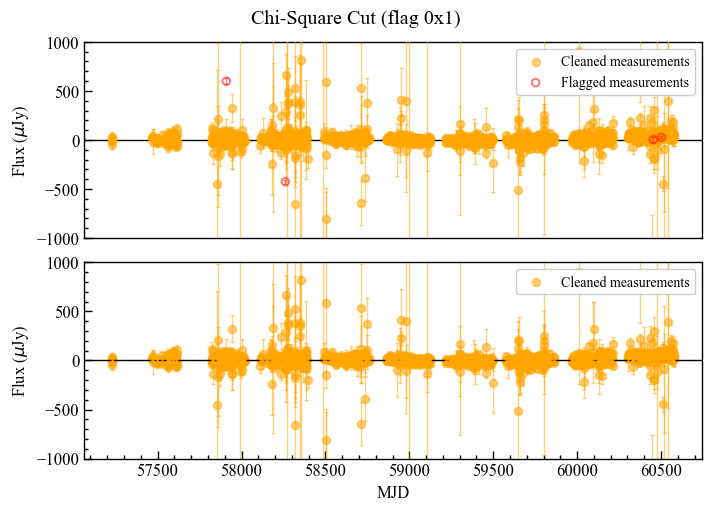

In [10]:
# ==== User Settings ====

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = -1000
YLIM_UPPER = 1000

# =======================

print(
    f'Applying chi-square cut of {x2_cut.max_value:0.2f} with {data["Pcontamination"]:0.2f}% contamination and {data["Ploss"]:0.2f}% loss...'
)
percent_cut = sn.apply_cut(x2_cut)
cut_list.add(x2_cut)
print("Success")
print(
    f"Total percent of SN light curve flagged with {hex(x2_cut.flag)}: {percent_cut:0.2f}%"
)

file_outputs[ChiSquareCut.name()] = f'\n\n### Chi-square cut\n\nChi-square cut {x2_cut.max_value:0.2f} selected with {data["Pcontamination"]:0.2f}% contamination and {data["Ploss"]:0.2f}% loss\n\nTotal percent of SN light curve flagged with {hex(x2_cut.flag)}: {percent_cut:0.2f}%'

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_cut(
    sn.lcs[0],
    x2_cut.flag,
    p.get_lims(
        lc=sn.lcs[0],
        indices=sn.lcs[0].get_good_indices(x2_cut.flag),
        custom_lims=custom_lims
    ),
    title=ChiSquareCut.name(),
    save_filename='chisquare_cut' if SAVE_PLOTS else None
)

## 5. Control light curve (3σ-clipped average) cut

While the chi-square and uncertainty cuts are effective in cutting out a majority of the bad measurements, tricky cases may require a larger set of control light curves that can be used as a basis of comparison for inconsistent flux. In order to account for this inconsistent flux, we can obtain, for example, 8 quality control forced photometry light curves in a 17" circle pattern around the SN location OR around a nearby bright object that may be poorly subtracting. Then, we use statistics from these control light curves to cut bad measurements from the SN light curve.

For a given epoch, we have 1 SN measurement for which we examine 8 control measurements within the same epoch. We know that if the control light curve measurements are NOT consistent with 0, this indicates something wrong with this epoch, so the SN measurement is unreliable. Therefore, we obtain statistics for the control light curves by calculating the 3σ-clipped average of the control flux. 

To read more about this cut, please refer to Section 3.1.4 of our paper (link at the top of this notebook).

In [11]:
# ==== User Settings ====

# Enter the bound for an epoch's maximum chi-square 
# (if chi-square value > x2_max, flag SN measurement):
X2_MAX = 2.5

# Enter the bound for an epoch's maximum abs(flux/dflux) ratio 
# (if |flux/dflux| > snr_max, flag SN measurement):
SNR_MAX = 3.0

# Enter the bound for an epoch's maximum number of clipped control measurements
# (if Nclip > Nclip_max, flag SN measurement):
NCLIP_MAX = 2

# Enter the bound for an epoch's minimum number of good control measurements
# (if Ngood < Ngood_min, flag SN measurement):
NGOOD_MIN = 4

# =======================

if not LOAD_CONTROLS or NUM_CONTROLS == 0:
    raise RuntimeError("Cannot apply this cut without loading control light curves; skipping procedure")

controls_cut = ControlLightCurveCut(
    flag=hexstring_to_int(config["controls_cut"]["bad_flag"]), 
    questionable_flag=hexstring_to_int(config["controls_cut"]["questionable_flag"]),
    x2_max=X2_MAX,
    x2_flag=hexstring_to_int(config["controls_cut"]["x2_flag"]),
    snr_max=SNR_MAX,
    snr_flag=hexstring_to_int(config["controls_cut"]["snr_flag"]),
    Nclip_max=NCLIP_MAX,
    Nclip_flag=hexstring_to_int(config["controls_cut"]["Nclip_flag"]),
    Ngood_min=NGOOD_MIN,
    Ngood_flag=hexstring_to_int(config["controls_cut"]["Ngood_flag"]),
)

print(f"\nApplying control light curve cut ({controls_cut}, x2_max={X2_MAX}, snr_max={SNR_MAX}, Nclip_max={NCLIP_MAX}, Ngood_min={NGOOD_MIN}):")
(
    x2_percent_cut,
    stn_percent_cut,
    Nclip_percent_cut,
    Ngood_percent_cut,
    questionable_percent_cut,
    percent_cut,
) = sn.apply_controls_cut(controls_cut, previous_flags=cut_list.get_previous_flags(ControlLightCurveCut.name()))
cut_list.add(controls_cut)
print("Success")

output = [
    f'Percent of SN light curve above x2_max bound ({hex(controls_cut.x2_flag)}): {x2_percent_cut:0.2f}%',
    f'Percent of SN light curve above snr_max bound ({hex(controls_cut.snr_flag)}): {stn_percent_cut:0.2f}%',
    f'Percent of SN light curve above Nclip_max bound ({hex(controls_cut.Nclip_flag)}): {Nclip_percent_cut:0.2f}%',
    f'Percent of SN light curve below Ngood_min bound ({hex(controls_cut.Ngood_flag)}): {Ngood_percent_cut:0.2f}%',
    f'Total percent of SN light curve flagged as questionable (not masked with control light curve flags but Nclip > 0) ({hex(controls_cut.questionable_flag)}): {questionable_percent_cut:0.2f}%',
    f"Total percent of SN light curve flagged as bad ({hex(controls_cut.flag)}): {percent_cut:0.2f}%"
]
print('\n'.join(output))
file_outputs[ControlLightCurveCut.name()] = f'\n\n### Control light curve cut\n\n'+'\n'.join(output)


Applying control light curve cut (Control Light Curve Cut: flag=0x400000, x2_max=2.5, snr_max=3.0, Nclip_max=2, Ngood_min=4):
Calculating control light curve statistics...
Success
Percent of SN light curve above x2_max bound (0x100): 3.05%
Percent of SN light curve above snr_max bound (0x200): 0.38%
Percent of SN light curve above Nclip_max bound (0x400): 0.07%
Percent of SN light curve below Ngood_min bound (0x800): 2.95%
Total percent of SN light curve flagged as questionable (not masked with control light curve flags but Nclip > 0) (0x80000): 11.49%
Total percent of SN light curve flagged as bad (0x400000): 6.39%


### Plot results

Saving plot: /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2023zkd/plots/controls_cut.png


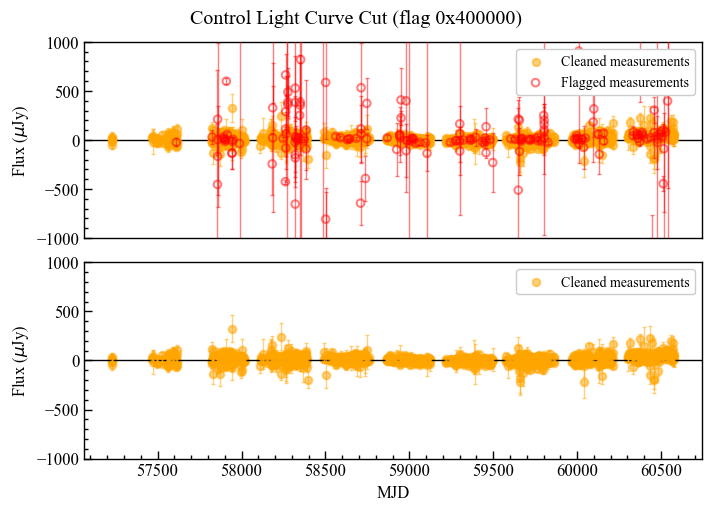

In [12]:
# ==== User Settings ====

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = -1000
YLIM_UPPER = 1000

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_cut(
    sn.lcs[0],
    controls_cut.flag,
    p.get_lims(
        lc=sn.lcs[0],
        indices=sn.lcs[0].get_good_indices(controls_cut.flag),
        custom_lims=custom_lims
    ),
    title=ControlLightCurveCut.name(),
    save_filename='controls_cut' if SAVE_PLOTS else None
)

## 6. Custom cuts

Below we offer the opportunity to apply a custom cut on any column. Feel free to duplicate the following cell to apply more than one custom cut.


Applying Custom Cut (column=duJy, flag=0x1000000, max=160)...
Success
Total percent of SN light curve flagged with 0x1000000: 3.02%
Saving plot: /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2023zkd/plots/custom_cut_duJy.png


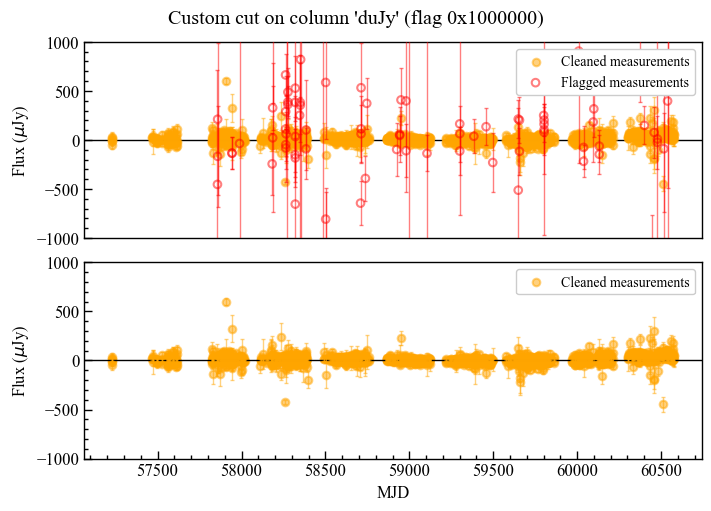

In [13]:
# ==== User Settings ====

# Enter the column name:
COLUMN_NAME = "duJy"

# Enter the desired min and max values for this column
# (min_value and max_value may both be set to None but not at the same time):
MAX_VALUE = 160
MIN_VALUE = None

# Enter the flag value to use in the mask column
# (any flag values at 0x1000000 and above are available for use):
FLAG = 0x1000000

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = -1000
YLIM_UPPER = 1000

# =======================

custom_cut = CustomCut(
    column=COLUMN_NAME, 
    min_value=MIN_VALUE, 
    max_value=MAX_VALUE, 
    flag=FLAG
)
if not custom_cut.can_apply_directly():
    raise RuntimeError("Custom cut parameters invalid; please enter a column name, a min and/or max value, and a flag value.")

print(f"\nApplying {custom_cut}...")
percent_cut = sn.apply_cut(custom_cut)
cut_list.add(custom_cut)
print("Success")
print(f"Total percent of SN light curve flagged with {hex(custom_cut.flag)}: {percent_cut:0.2f}%")

file_outputs[custom_cut.name()] = f"\n\n### Custom cut on column '{custom_cut.column}'\n\nTotal percent of SN light curve flagged ({hex(custom_cut.flag)}): {percent_cut:0.2f}%"

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_cut(
    sn.lcs[0],
    custom_cut.flag,
    p.get_lims(
        lc=sn.lcs[0],
        indices=sn.lcs[0].get_good_indices(custom_cut.flag),
        custom_lims=custom_lims
    ),
    title=f"Custom cut on column '{custom_cut.column}'",
    save_filename=f"custom_cut_{COLUMN_NAME}" if SAVE_PLOTS else None
)

## Remove any cuts you applied but didn't like

At some point you may have applied a cut and didn't like how it turned out. That's okay! Go back to the plot for that cut and copy the corresponding `flag` hex value. Then paste it into the `flags_to_remove` list in the cell below and it will be removed from all light curves' mask column, as well as the output README.

In this example, we remove the previous example custom cut. 

In [14]:
# ==== User Settings ====

# Enter the flag values you'd like to remove from the mask column:
FLAGS_TO_REMOVE = [0x1000000]

# =======================

# remove flags from mask column of all light curves
combined_flags = reduce(lambda x, y: x | y, FLAGS_TO_REMOVE, 0)
sn.remove_flag(combined_flags)

# remove from cut list
for flag in FLAGS_TO_REMOVE:
    cut_list.remove_by_flag(flag)


## Plot the ATLAS light curve with all previous cuts

Saving plot: /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2023zkd/plots/all_previous_cuts.png
Saving plot: /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2023zkd/plots/cleaned.png


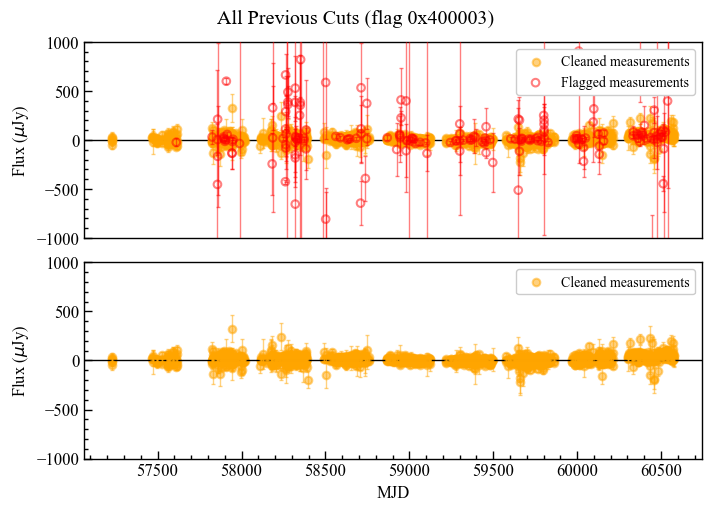

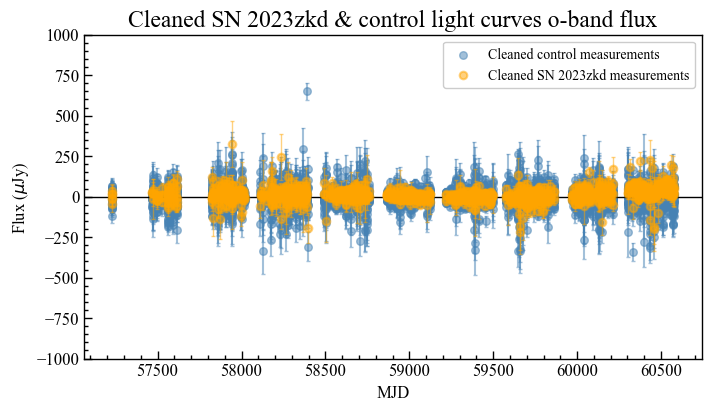

In [ ]:
# ==== User Settings ====

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = -1000
YLIM_UPPER = 1000

# =======================

previous_flags = cut_list.get_previous_flags(BadDayCut.name())

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

lims = p.get_lims(
    lc=sn.lcs[0],
    indices=sn.lcs[0].get_good_indices(previous_flags),
    custom_lims=custom_lims
)

fig = p.plot_cut(
    sn.lcs[0], 
    previous_flags, 
    lims, 
    title="All previous cuts", 
    save_filename="all_previous_cuts" if SAVE_PLOTS else None
)

fig = p.plot_cleaned_SN(
    sn, 
    previous_flags, 
    lims, 
    plot_controls=True, 
    plot_flagged=False, 
    save=SAVE_PLOTS
)

## 7. Averaging and cutting bad bins

Our goal is to identify and cut out bad MJD bins by taking a 3σ-clipped average of each bin. For each bin, we calculate the 3σ-clipped average of any SN measurements falling within that bin and use that average as our flux for that bin. Because the ATLAS survey takes about 4 exposures every 2 days, we usually average together approximately 4 measurements per epoch. However, out of these 4 exposures, only measurements not cut in the previous methods are averaged in the 3σ-clipped average cut. (The exception to this statement would be the case that all 4 measurements are cut in previous methods; in this case, they are averaged anyway and flagged as a bad bin.)

To read more about this cut, please refer to Section 3.3 of our paper (link at the top of this notebook).

For this part of the cleaning, we still need to improve the cutting at the peak of the SN (important epochs are sometimes cut, maybe due to fast rise, etc.).

In [18]:
# ==== User Settings ====

# Enter the size of MJD bins in days:
MJD_BIN_SIZE = 1.0

# Enter the sigma limit when converting flux to magnitude 
# (magnitudes are limits when dmagnitudes are NaN):
FLUX2MAG_SIGMALIMIT = 3

# =======================

previous_flags = cut_list.get_previous_flags(BadDayCut.name())

badday_cut = BadDayCut(
    flag=hexstring_to_int(config["averaging"]["flag"]),
    mjd_bin_size=MJD_BIN_SIZE,
    x2_max=float(config["averaging"]["x2_max"]),
    Nclip_max=int(config["averaging"]["Nclip_max"]),
    Ngood_min=int(config["averaging"]["Ngood_min"]),
    ixclip_flag=hexstring_to_int(config["averaging"]["ixclip_flag"]),
    smallnum_flag=hexstring_to_int(config["averaging"]["smallnum_flag"]),
)

print(f"\nApplying bad day cut (averaging) ({badday_cut}):")
avg_sn, percent_cut = sn.apply_badday_cut(
    badday_cut, previous_flags, flux2mag_sigmalimit=FLUX2MAG_SIGMALIMIT
)
cut_list.add(badday_cut)
print("Success")
print(
    f"Total percent of SN light curve flagged as bad ({hex(cut_list.get_all_flags())}): {percent_cut:0.2f}"
)

file_outputs[BadDayCut.name()] = f'\n\nAfter the cuts are applied, the light curves are resaved with the new "Mask" column.\nTotal percent of SN light curve flagged as bad ({hex(cut_list.get_all_flags())}): {percent_cut:0.2f}\n\n### Bad day cut (averaging)\n\nThe averaged light curves are then saved in a new file with the MJD bin size added to the filename.'


Applying bad day cut (averaging) (Bad Day Cut: flag=0x800000):
Now averaging SN light curve...


/Users/sofiarest/My Drive/College/STScI Research Paper/atclean/pdastro.py:720: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.t = pd.concat([self.t, pd.DataFrame([dicti])], axis=0, ignore_index=True)


Now averaging control light curve 1...


/Users/sofiarest/My Drive/College/STScI Research Paper/atclean/pdastro.py:720: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.t = pd.concat([self.t, pd.DataFrame([dicti])], axis=0, ignore_index=True)


Now averaging control light curve 2...


...

Now averaging control light curve 7...


/Users/sofiarest/My Drive/College/STScI Research Paper/atclean/pdastro.py:720: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.t = pd.concat([self.t, pd.DataFrame([dicti])], axis=0, ignore_index=True)


Now averaging control light curve 8...


/Users/sofiarest/My Drive/College/STScI Research Paper/atclean/pdastro.py:720: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.t = pd.concat([self.t, pd.DataFrame([dicti])], axis=0, ignore_index=True)


Success
Total percent of SN light curve flagged as bad (0xc83f03): 81.29


### Plot results

Saving plot: /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2023zkd/plots/badday_cut.png
Saving plot: /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2023zkd/plots/averaged.png


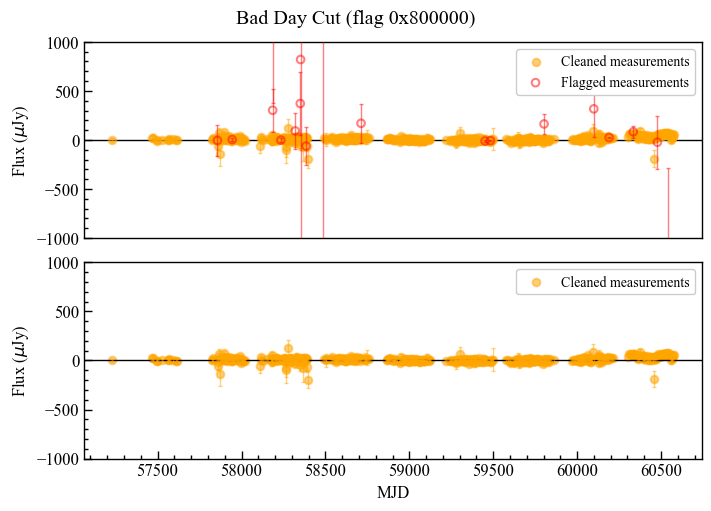

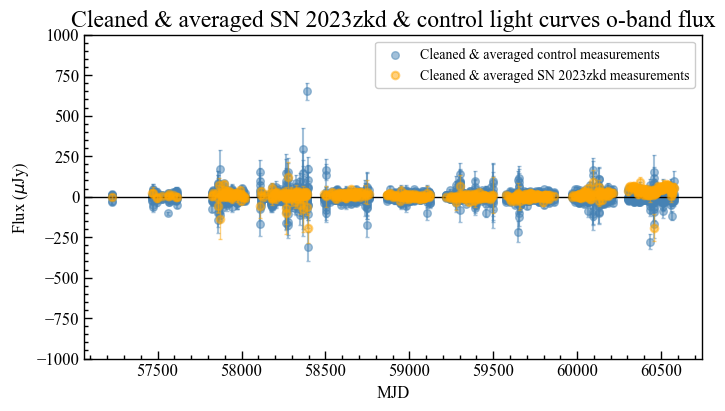

In [ ]:
# ==== User Settings ====

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = -1000
YLIM_UPPER = 1000

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

lims = p.get_lims(
    lc=avg_sn.lcs[0],
    indices=avg_sn.lcs[0].get_good_indices(badday_cut.flag),
    custom_lims=custom_lims
)

fig = p.plot_cut(
    avg_sn.lcs[0],
    badday_cut.flag,
    lims,
    title=BadDayCut.name(),
    save_filename="badday_cut" if SAVE_PLOTS else None
)

fig = p.plot_averaged_SN(
    avg_sn, 
    badday_cut.flag, 
    lims, 
    plot_controls=True, 
    plot_flagged=False, 
    save=SAVE_PLOTS
)

## Save cleaned and binned light curves to output directory

In [20]:
# save cleaned SN and control light curves
sn.save_all(OUTPUT_DIR, overwrite=True)

if cut_list.has(BadDayCut.name()):
    # save averaged SN and control light curves
    avg_sn.save_all(OUTPUT_DIR, overwrite=True)


Dropping extra columns and saving cleaned SN light curve and 8 cleaned control light curves...
Success

Dropping extra columns and saving averaged SN light curve and 8 averaged control light curves...
Success


## Save output README

In [21]:
write_to_file(README_PATH, ''.join(file_outputs.values()), mode='w')

True